## The goal is to come up with a predictive model which helps prioritize quotes with highest chance of cross selling the product

  ### Case Details: 
  
  #### Existing customers have been quoted for "Product X" and the status of each quote is marked as Sold or Lost. The relavent data is stored in three files: 
  #### 1. `employers.csv` - holds basic customer data, such as number of years as a client, number of employees and Industry type. 
  #### 2. `geography.csv` - contains general geographic location by zip code, such as longitude, latitude, population etc... 
  #### 3. `quotes.csv` - contains the quote status (lost or sold) by the customer's ID. 
  #### 4. `dictionary.csv` - contains additional information on what each data set contains  

In [136]:
!pip install scikit-learn

In [137]:
# Import Packages

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans


from scipy import stats
from scipy.stats import norm, skew




In [138]:
# Load Data
employer_data = pd.read_csv("data/employers.csv", encoding="cp1252")
geography_data = pd.read_csv("data/geography.csv", encoding="cp1252")
quotes_data = pd.read_csv("data/quotes.csv", encoding="cp1252")


### Data Cleaning

In [139]:
# Inspect employer table
employer_data.info()
employer_data.head()

# Check for duplicates
employer_data["EmployerId"].duplicated().sum()
dupe_employers =employer_data[employer_data["EmployerId"].duplicated(keep=False)].sort_values("EmployerId")
dupe_employers

#Then check whether only Industry differs or other columns differ too
dupe_employers.groupby("EmployerId").nunique()

# More focused duplicates
dupe_employers.groupby("EmployerId")["Industry"].unique()

# Keep the first occurrence of each duplicate and drop the rest
employer_data_clean = employer_data.drop_duplicates(subset="EmployerId", keep="first")

# Create a new dataframe with the count of unique industries per employer for feature engineering
industry_counts = (
    employer_data
    .groupby("EmployerId")["Industry"]
    .nunique()
    .reset_index(name="industry_count")
)


<class 'pandas.DataFrame'>
RangeIndex: 65356 entries, 0 to 65355
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   EmployerId       65356 non-null  int64
 1   ClientTenure     65356 non-null  int64
 2   Employees        65356 non-null  int64
 3   Industry         57125 non-null  str  
 4   NetworkStrength  65356 non-null  str  
 5   ZipCode          65356 non-null  str  
dtypes: int64(3), str(3)
memory usage: 3.0 MB


In [140]:
geography_data.info()

# Check for duplicates
geography_data["zip"].duplicated().sum()
#geography_data[geography_data["zip"].duplicated(keep=False)].sort_values("zip")

<class 'pandas.DataFrame'>
RangeIndex: 43318 entries, 0 to 43317
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   zip         43318 non-null  int64  
 1   city        43318 non-null  str    
 2   latitude    43318 non-null  float64
 3   longitude   43318 non-null  float64
 4   fips        43318 non-null  int64  
 5   county      43318 non-null  str    
 6   population  43318 non-null  int64  
 7   state       43318 non-null  str    
 8   cbsa        43318 non-null  str    
 9   cbsa_name   43318 non-null  str    
dtypes: float64(2), int64(3), str(5)
memory usage: 3.3 MB


np.int64(0)

In [141]:
quotes_data.info()

# Check for duplicates
quotes_data["EmployerId"].duplicated().sum()
quotes_data[quotes_data["EmployerId"].duplicated(keep=False)].sort_values("EmployerId")

# Remove duplicates from quotes data
quotes_data_clean = quotes_data.drop_duplicates(
    subset=["EmployerId"],
    keep="first"
)
quotes_data_clean["EmployerId"].duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 7398 entries, 0 to 7397
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   EmployerId  7398 non-null   int64
 1   Offered     7398 non-null   str  
 2   Status      7398 non-null   str  
dtypes: int64(1), str(2)
memory usage: 173.5 KB


np.int64(0)

In [142]:
#Change Zipcode columns to same name in both tables
geography_data.rename(columns={"zip": "ZipCode"}, inplace=True)

# Change merge columns to same Dtypes (numeric)
employer_data_clean["ZipCode"] = pd.to_numeric(
    employer_data_clean["ZipCode"],
    errors="coerce"
).astype("Int64")

In [143]:
# Merge Dataframes
data = (quotes_data_clean.merge(employer_data_clean, on="EmployerId", how="left").merge(geography_data, on="ZipCode", how="left"))
data.head()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7396 entries, 0 to 7395
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   EmployerId       7396 non-null   int64  
 1   Offered          7396 non-null   str    
 2   Status           7396 non-null   str    
 3   ClientTenure     7396 non-null   int64  
 4   Employees        7396 non-null   int64  
 5   Industry         5998 non-null   str    
 6   NetworkStrength  7396 non-null   str    
 7   ZipCode          7389 non-null   Int64  
 8   city             7377 non-null   str    
 9   latitude         7377 non-null   float64
 10  longitude        7377 non-null   float64
 11  fips             7377 non-null   float64
 12  county           7377 non-null   str    
 13  population       7377 non-null   float64
 14  state            7377 non-null   str    
 15  cbsa             7377 non-null   str    
 16  cbsa_name        7377 non-null   str    
dtypes: Int64(1), float64(4), 

In [144]:
# Create a copy of the data frame for ML
ml_data = data.copy()

# Normalize column names
ml_data.columns = ml_data.columns.str.lower()

# Normalize location columns
cols_to_normalize = ["city", "county", "cbsa_name"]

ml_data[cols_to_normalize] = ml_data[cols_to_normalize].apply(
    lambda col: col.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)
)
ml_data.head()

,employerid,offered,status,clienttenure,employees,industry,networkstrength,zipcode,city,latitude,longitude,fips,county,population,state,cbsa,cbsa_name
0,363773443,ProductX,Lost,4,55,I26,0.1011,77075,houston,29.620881,-95.26018,48201.0,harris_county,4092459.0,TX,26420,houston-the_woodlands-sugar_land
1,186941116,ProductX,Lost,5,10,I12,-0.0333,6002,bloomfield,41.832798,-72.72642,9003.0,hartford_county,894014.0,CT,25540,hartford-west_hartford-east_hartford
2,511147993,ProductX,Lost,10,48,I19,0.8138,30067,marietta,33.933002,-84.47633,13067.0,cobb_county,688078.0,GA,12060,atlanta-sandy_springs-roswell
3,46777684,ProductX,Lost,6,26,I20,-0.1963,2886,warwick,41.705478,-71.45119,44003.0,kent_county,166158.0,RI,39300,providence-warwick
4,115068663,ProductX,Lost,6,64,I27,0.1815,60440,bolingbrook,41.703097,-88.07462,17197.0,will_county,677560.0,IL,16980,chicago-naperville-elgin


In [145]:
# Create dataframe for eda
eda_data = ml_data.copy()

# Inspect null values in industry column
print(eda_data["industry"].isna().sum())

# Fill null values in industry column with "unknown" and encode target variable
eda_data["industry"] = eda_data["industry"].fillna("unknown")
eda_data["status"] = eda_data["status"].str.strip().str.lower().map({"sold": 1, "lost": 0})

# Inspect sold rate by industry
industry_summary = (
    eda_data
    .groupby("industry")["status"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

industry_summary # This shows there's a lot of weight in Sold status for unknown industry values. Its best to impute these NaN values as unknown than to drop them.

1398


,count,mean
industry,,
unknown,1398,0.365522
I03,16,0.250000
I08,32,0.250000
I19,363,0.239669
I10,17,0.235294
I18,51,0.215686
I26,210,0.214286
I21,235,0.212766
I16,57,0.210526


In [146]:
# Drop rows with missing values, except for the industry column
ml_data = ml_data.dropna(
    subset=[
        "employerid",
        "offered",
        "status",
        "clienttenure",
        "employees",
        "networkstrength",
        "zipcode",
        "city",
        "latitude",
        "longitude",
        "fips",
        "county",
        "population",
        "state",
        "cbsa",
        "cbsa_name"
    ]
)
ml_data.info()

<class 'pandas.DataFrame'>
Index: 7377 entries, 0 to 7395
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   employerid       7377 non-null   int64  
 1   offered          7377 non-null   str    
 2   status           7377 non-null   str    
 3   clienttenure     7377 non-null   int64  
 4   employees        7377 non-null   int64  
 5   industry         5984 non-null   str    
 6   networkstrength  7377 non-null   str    
 7   zipcode          7377 non-null   Int64  
 8   city             7377 non-null   str    
 9   latitude         7377 non-null   float64
 10  longitude        7377 non-null   float64
 11  fips             7377 non-null   float64
 12  county           7377 non-null   str    
 13  population       7377 non-null   float64
 14  state            7377 non-null   str    
 15  cbsa             7377 non-null   str    
 16  cbsa_name        7377 non-null   str    
dtypes: Int64(1), float64(4), int64

In [147]:
# Examine the categorical columns
categorical_columns = ml_data.select_dtypes(include=['object', 'category'])

# Print the unique values for each categorical column
for col in categorical_columns:
    print(f"\n{col}")
    print(sorted(ml_data[col].dropna().unique()))


offered
['ProductX']

status
['Lost', 'Sold']

industry
['I01', 'I02', 'I03', 'I04', 'I05', 'I06', 'I07', 'I08', 'I09', 'I10', 'I11', 'I12', 'I13', 'I14', 'I15', 'I16', 'I17', 'I18', 'I19', 'I20', 'I21', 'I22', 'I23', 'I24', 'I25', 'I26', 'I27']

networkstrength
['-0.0040', '-0.0066', '-0.0090', '-0.0094', '-0.0168', '-0.0176', '-0.0179', '-0.0188', '-0.0233', '-0.0285', '-0.0319', '-0.0333', '-0.0348', '-0.0378', '-0.0383', '-0.0428', '-0.0432', '-0.0451', '-0.0455', '-0.0482', '-0.0486', '-0.0546', '-0.0555', '-0.0574', '-0.0575', '-0.0583', '-0.0594', '-0.0624', '-0.0661', '-0.0667', '-0.0670', '-0.0671', '-0.0674', '-0.0693', '-0.0701', '-0.0748', '-0.0760', '-0.0766', '-0.0771', '-0.0801', '-0.0802', '-0.0879', '-0.0925', '-0.0939', '-0.0953', '-0.0958', '-0.0969', '-0.0971', '-0.1012', '-0.1040', '-0.1105', '-0.1118', '-0.1124', '-0.1127', '-0.1144', '-0.1181', '-0.1182', '-0.1185', '-0.1201', '-0.1225', '-0.1226', '-0.1242', '-0.1249', '-0.1254', '-0.1265', '-0.1283', '-0.1301'

C:\Users\exi0\AppData\Local\Temp\1\ipykernel_21444\1689879238.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = ml_data.select_dtypes(include=['object', 'category'])


In [148]:
# return rows with '?' for cbsa_name
ml_data[ml_data['cbsa_name'] == '?']

# Change the '?' values in cbsa and cbsa_name to NA for imputation
ml_data['cbsa'] = ml_data['cbsa'].replace('?', pd.NA)
ml_data['cbsa_name'] = ml_data['cbsa_name'].replace('?', pd.NA)
ml_data.info()

<class 'pandas.DataFrame'>
Index: 7377 entries, 0 to 7395
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   employerid       7377 non-null   int64  
 1   offered          7377 non-null   str    
 2   status           7377 non-null   str    
 3   clienttenure     7377 non-null   int64  
 4   employees        7377 non-null   int64  
 5   industry         5984 non-null   str    
 6   networkstrength  7377 non-null   str    
 7   zipcode          7377 non-null   Int64  
 8   city             7377 non-null   str    
 9   latitude         7377 non-null   float64
 10  longitude        7377 non-null   float64
 11  fips             7377 non-null   float64
 12  county           7377 non-null   str    
 13  population       7377 non-null   float64
 14  state            7377 non-null   str    
 15  cbsa             7106 non-null   str    
 16  cbsa_name        7106 non-null   str    
dtypes: Int64(1), float64(4), int64

In [149]:
# Check for duplicate 'unique' values in columns
cols_to_check = ["city", "county", "cbsa_name"]

for col in cols_to_check:
    normalized = (
        ml_data[col]
        .astype("string")
        .str.strip()
        .str.lower()
        .str.replace(r"[\s_]+", "", regex=True)
    )

    similar_values = (
        pd.DataFrame({
            "original": ml_data[col],
            "normalized": normalized
        })
        .dropna()
        .drop_duplicates()
        .groupby("normalized")["original"]
        .agg(lambda x: sorted(set(x)))
    )

    print(f"\n{col}")
    display(similar_values[similar_values.apply(len) > 1])
# This shows that la_grange and lagrange might be the same value, just formatted differently.


city


normalized
lagrange    [la_grange, lagrange]
Name: original, dtype: object


county


Series([], Name: original, dtype: object)


cbsa_name


Series([], Name: original, dtype: object)

In [150]:
# Further investigate the unique duplicated value in city column
print(ml_data[ml_data['city'] == 'la_grange'])
print(ml_data[ml_data['city'] == 'lagrange'])
# These two values might be different, so keep it as is

      employerid   offered status  clienttenure  employees industry  \
1187      813145  ProductX   Lost            30         16      I27   
2420      504090  ProductX   Lost            25         50      I20   
2633   515525985  ProductX   Lost             2         33      I20   
4897   629238731  ProductX   Lost             1         40      I19   
5049   624635166  ProductX   Sold             1         57      I26   
5057   571736781  ProductX   Lost             2         36      I23   
6055   340363577  ProductX   Lost            23         19      I22   

     networkstrength  zipcode       city   latitude  longitude     fips  \
1187          0.1056    60525  la_grange  41.788536  -87.87605  17031.0   
2420          0.1056    60525  la_grange  41.788536  -87.87605  17031.0   
2633          0.1056    60525  la_grange  41.788536  -87.87605  17031.0   
4897         -1.3829    78945  la_grange  29.909764  -96.87450  48149.0   
5049          0.1056    60525  la_grange  41.788536  -87

In [151]:
# Inspect numeric columns for non-numeric values
expected_numeric_cols = [
    "clienttenure",
    "employees",
    "networkstrength",
    "zipcode",
    "latitude",
    "longitude",
    "fips",
    "population"
]

non_numeric_summary = []

for col in expected_numeric_cols:
    numeric_version = pd.to_numeric(ml_data[col], errors="coerce")

    bad_values = ml_data.loc[
        numeric_version.isna() & ml_data[col].notna(),
        col
    ]

    non_numeric_summary.append({
        "column": col,
        "non_numeric_count": bad_values.shape[0],
        "unique_bad_values": bad_values.unique()
    })

non_numeric_summary = pd.DataFrame(non_numeric_summary)
non_numeric_summary

,column,non_numeric_count,unique_bad_values
0,clienttenure,0,[]
1,employees,0,[]
2,networkstrength,59,[?]
3,zipcode,0,[]
4,latitude,0,[]
5,longitude,0,[]
6,fips,0,[]
7,population,0,[]


In [152]:
# Replace any remaining non-numeric values in networkstrength to NaN
ml_data["networkstrength"] = ml_data["networkstrength"].replace(["?", "Nan", "NaN", "nan"], pd.NA)

# Convert networkstrength to numeric
ml_data["networkstrength"] = pd.to_numeric(ml_data["networkstrength"], errors="coerce")

# Check 
ml_data["networkstrength"].isna().sum()

np.int64(59)

In [153]:
# Encode the target variable
ml_data["status"].unique()
ml_data["status"] = ml_data["status"].str.strip().str.lower()
ml_data["status"] = ml_data["status"].map({"sold": 1, "lost": 0})
ml_data.head()

,employerid,offered,status,clienttenure,employees,industry,networkstrength,zipcode,city,latitude,longitude,fips,county,population,state,cbsa,cbsa_name
0,363773443,ProductX,0,4,55,I26,0.1011,77075,houston,29.620881,-95.26018,48201.0,harris_county,4092459.0,TX,26420,houston-the_woodlands-sugar_land
1,186941116,ProductX,0,5,10,I12,-0.0333,6002,bloomfield,41.832798,-72.72642,9003.0,hartford_county,894014.0,CT,25540,hartford-west_hartford-east_hartford
2,511147993,ProductX,0,10,48,I19,0.8138,30067,marietta,33.933002,-84.47633,13067.0,cobb_county,688078.0,GA,12060,atlanta-sandy_springs-roswell
3,46777684,ProductX,0,6,26,I20,-0.1963,2886,warwick,41.705478,-71.45119,44003.0,kent_county,166158.0,RI,39300,providence-warwick
4,115068663,ProductX,0,6,64,I27,0.1815,60440,bolingbrook,41.703097,-88.07462,17197.0,will_county,677560.0,IL,16980,chicago-naperville-elgin


In [ ]:
# Store numeric columns
numeric_columns = ml_data.select_dtypes(include=[np.number])

In [157]:
# Outlier detection
outlier_summary = []

for col in numeric_columns:
    q1 = ml_data[col].quantile(0.25)
    q3 = ml_data[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = ml_data[
        (ml_data[col] < lower_bound) |
        (ml_data[col] > upper_bound)
    ]

    outlier_summary.append({
        "column": col,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outliers.shape[0],
        "outlier_percent": outliers.shape[0] / ml_data.shape[0]
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary.sort_values("outlier_percent", ascending=False)

,column,lower_bound,upper_bound,outlier_count,outlier_percent
1,status,0.000000e+00,0.000000e+00,1654,0.224210
9,population,-1.320886e+06,2.716310e+06,821,0.111292
3,employees,-5.900000e+01,1.410000e+02,812,0.110072
7,longitude,-1.177224e+02,-6.163765e+01,610,0.082689
4,networkstrength,-1.093400e+00,1.521800e+00,149,0.020198
2,clienttenure,-1.900000e+01,3.700000e+01,94,0.012742
6,latitude,2.129626e+01,5.468607e+01,10,0.001356
0,employerid,-8.853398e+08,1.477658e+09,0,0.000000
5,zipcode,-3.673550e+04,1.421485e+05,0,0.000000
8,fips,-2.049600e+04,7.957600e+04,0,0.000000


Based on these results, columns of interest to dive deeper in are population, employees, longitude, networkstrength, and clienttenure and latitude

In [158]:
# Create a dataframe of outlier columns of interest
outlier_cols_to_inspect = [
    "employees",
    "population",
    "longitude",
    "networkstrength",
    "clienttenure",
    "latitude"
]

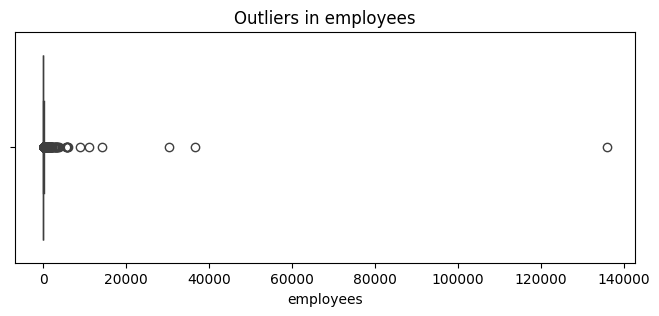

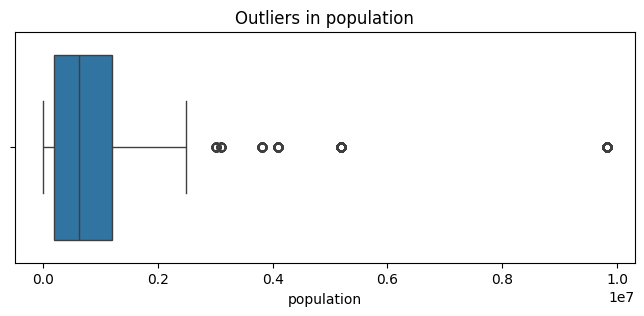

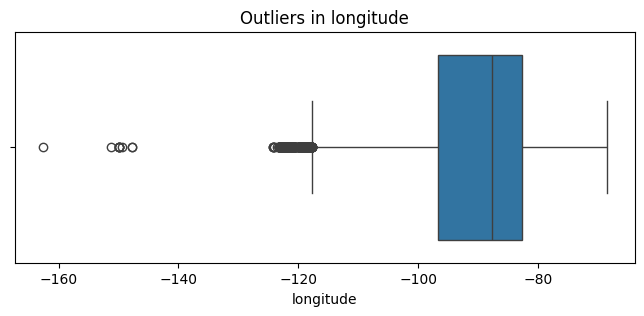

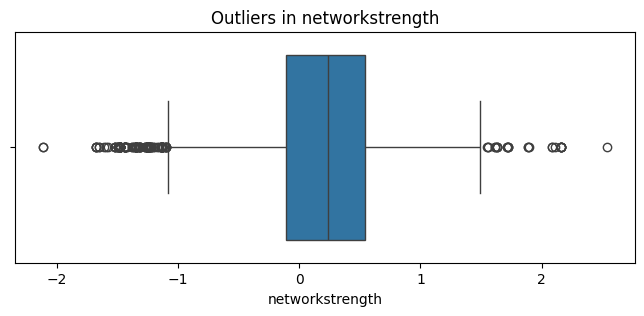

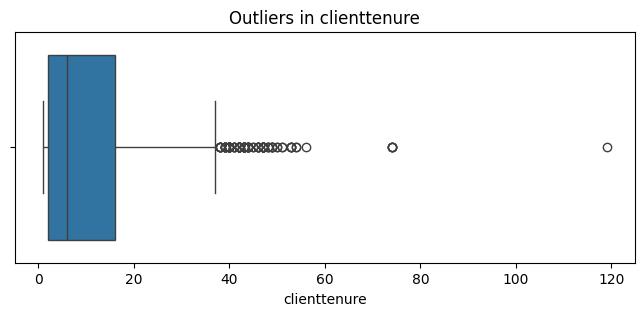

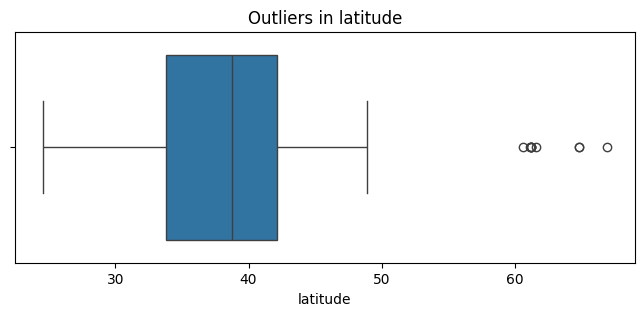

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create boxplots for outlier columns
for col in outlier_cols_to_inspect:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=ml_data[col])
    plt.title(f"Outliers in {col}")
    plt.show()

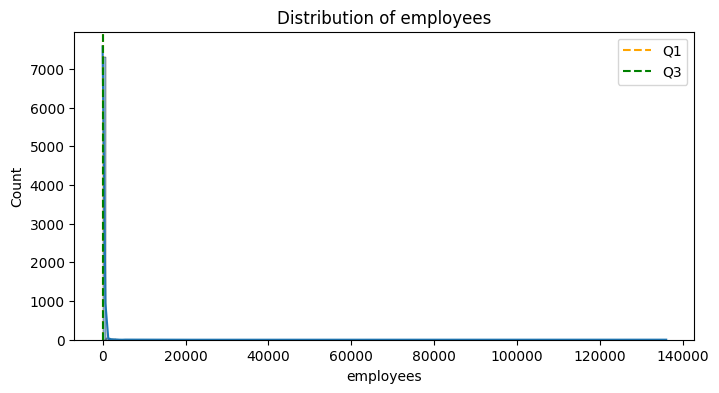

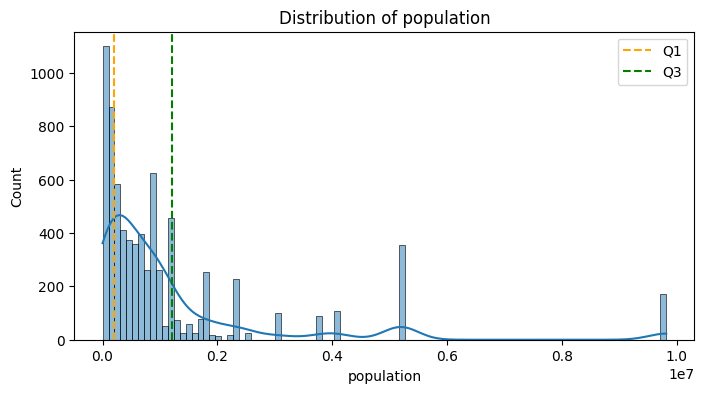

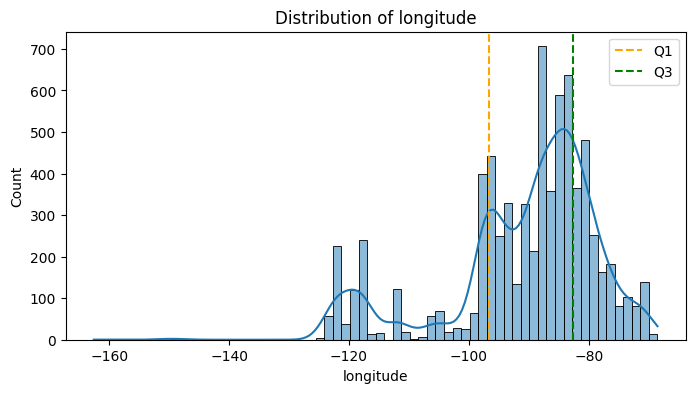

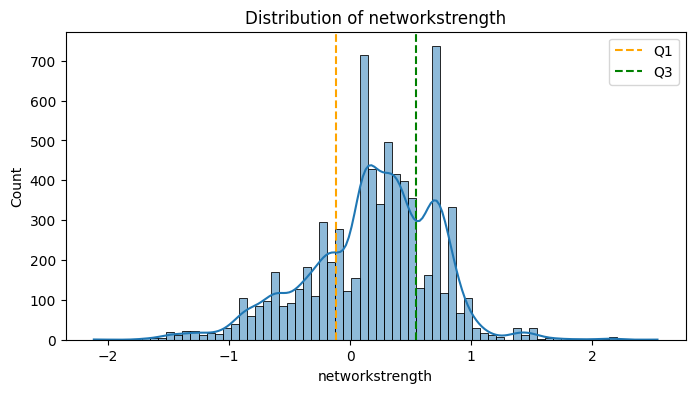

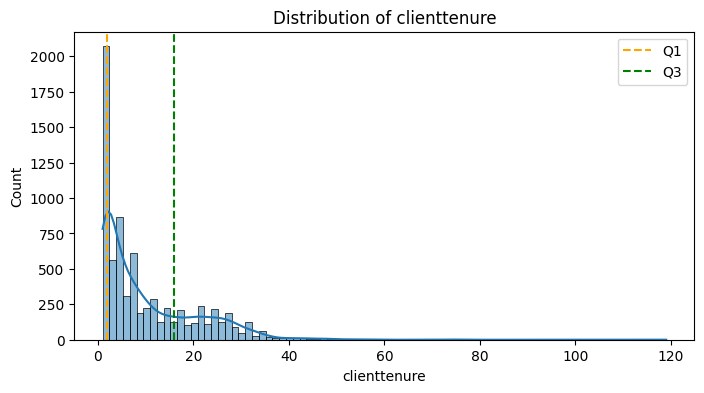

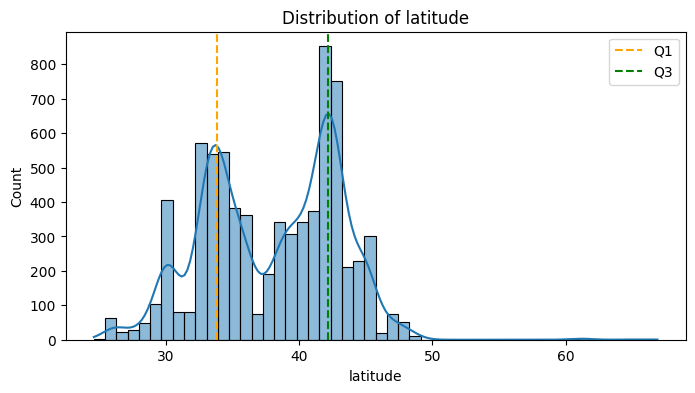

In [ ]:
# Visualize the distributions of outlier columns
for col in outlier_cols_to_inspect:
    plt.figure(figsize=(8, 4))
    sns.histplot(ml_data[col], kde=True)
    plt.axvline(ml_data[col].quantile(0.25), color="orange", linestyle="--", label="Q1")
    plt.axvline(ml_data[col].quantile(0.75), color="green", linestyle="--", label="Q3")
    plt.title(f"Distribution of {col}")
    plt.legend()
    plt.show() # lat and long are skewed, but rightfully so because of their location coordinattes. Netweork strength is actually now very skewed

In [ ]:
# Investigate outliers in employees column
high_employee_rows = ml_data[ml_data["employees"] > 1500]

high_employee_rows # This shows that there are 37 rows that is account for the outlier, the numbers seem possible and plausible so might not delete

,employerid,offered,status,clienttenure,employees,industry,networkstrength,zipcode,city,latitude,longitude,fips,county,population,state,cbsa,cbsa_name
239,638308050,ProductX,1,3,3279,I20,0.0842,38801,tupelo,34.236150,-88.756650,28081.0,lee_county,82910.0,MS,46180,tupelo
446,626296,ProductX,0,31,3082,I08,0.6859,48092,warren,42.511293,-83.059700,26099.0,macomb_county,840978.0,MI,19820,detroit-warren-dearborn
960,505883,ProductX,0,16,2692,I25,0.1490,75034,frisco,33.143792,-96.839380,48085.0,collin_county,782341.0,TX,19100,dallas-fort_worth-arlington
1153,694470753,ProductX,0,1,1628,NaN,-0.7957,36608,mobile,30.690440,-88.197010,1097.0,mobile_county,412992.0,AL,33660,mobile
1256,531791870,ProductX,0,6,2131,I03,0.8253,44141,brecksville,41.307688,-81.618350,39035.0,cuyahoga_county,1280122.0,OH,17460,cleveland-elyria
1466,399473385,ProductX,0,21,2098,I05,0.2229,38138,germantown,35.088885,-89.806770,47157.0,shelby_county,927644.0,TN,32820,memphis
1515,434710,ProductX,0,10,5721,I27,-0.4309,35203,birmingham,33.519055,-86.809700,1073.0,jefferson_county,658466.0,AL,13820,birmingham-hoover
1683,764604,ProductX,0,12,36687,I20,0.3200,37214,nashville,36.166956,-86.668690,47037.0,davidson_county,626681.0,TN,34980,nashville-davidson--murfreesboro--franklin
1844,134711142,ProductX,0,13,1721,I23,0.0435,31701,albany,31.580774,-84.160440,13095.0,dougherty_county,94565.0,GA,10500,albany
1938,457072,ProductX,0,34,2202,I25,0.7075,33316,fort_lauderdale,26.101114,-80.129310,12011.0,broward_county,1748066.0,FL,33100,miami-fort_lauderdale-west_palm_beach


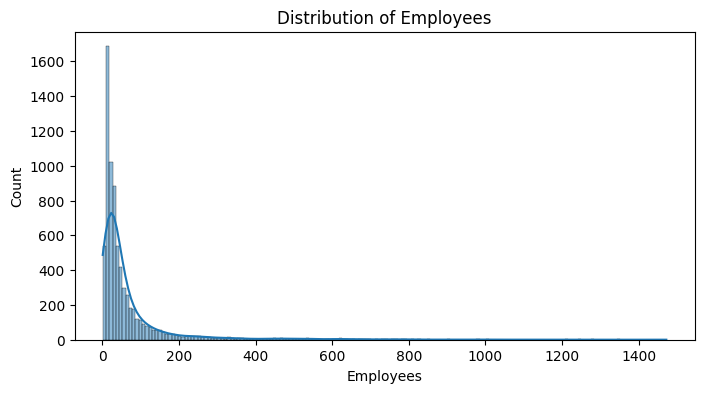

In [192]:
# Use eda_data dataframe to see if deleting the outlier row affects distribution
eda_data = ml_data.drop(high_employee_rows.index)

# Graph distribution plot of employee column without the outlier
plt.figure(figsize=(8, 4))
sns.histplot(eda_data["employees"], kde=True)
plt.title("Distribution of Employees")
plt.xlabel("Employees")
plt.ylabel("Count")
plt.show()

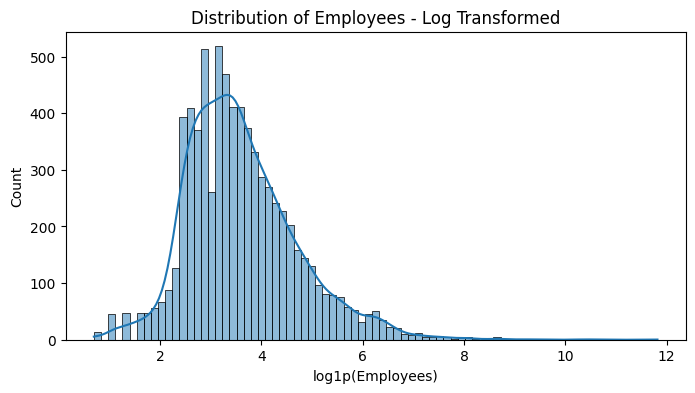

In [ ]:
# Log transform employees column to see if dropping or log is best
employees_log = np.log1p(ml_data["employees"])

plt.figure(figsize=(8, 4))
sns.histplot(employees_log, kde=True)
plt.title("Distribution of Employees - Log Transformed")
plt.xlabel("log1p(Employees)")
plt.ylabel("Count")
plt.show() #might actually be better to just log transform instead of dopping because these values are plossible and plausible. And the log transform distributes etter than deleting

In [198]:
# Investigate outliers in employees column
low_employee_rows = ml_data[ml_data["employees"] < 0]

low_employee_rows 

,employerid,offered,status,clienttenure,employees,industry,networkstrength,zipcode,city,latitude,longitude,fips,county,population,state,cbsa,cbsa_name


In [ ]:
# Investigate client tenure column for outliers
high_tenure_rows = ml_data[ml_data["clienttenure"] > 60]

high_tenure_rows #just 5 rows, doesn't seem unrealistic

,employerid,offered,status,clienttenure,employees,industry,networkstrength,zipcode,city,latitude,longitude,fips,county,population,state,cbsa,cbsa_name
548,672317,ProductX,0,74,90,I12,0.3197,32789,winter_park,28.598677,-81.35594,12095.0,orange_county,1145956.0,FL,36740,orlando-kissimmee-sanford
3073,550396,ProductX,0,74,42,I20,2.0892,44601,alliance,40.917908,-81.11641,39151.0,stark_county,375586.0,OH,15940,canton-massillon
3751,689811437,ProductX,1,74,20,I14,0.4496,94063,redwood_city,37.483504,-122.21440,6081.0,san_mateo_county,718451.0,CA,41860,san_francisco-oakland-hayward
4186,457885477,ProductX,0,119,52,I25,0.1007,63144,saint_louis,38.619152,-90.34964,29189.0,st._louis_county,998954.0,MO,41180,st._louis
4220,686202,ProductX,0,74,1841,I24,0.6907,48377,novi,42.511766,-83.47314,26125.0,oakland_county,1202362.0,MI,19820,detroit-warren-dearborn


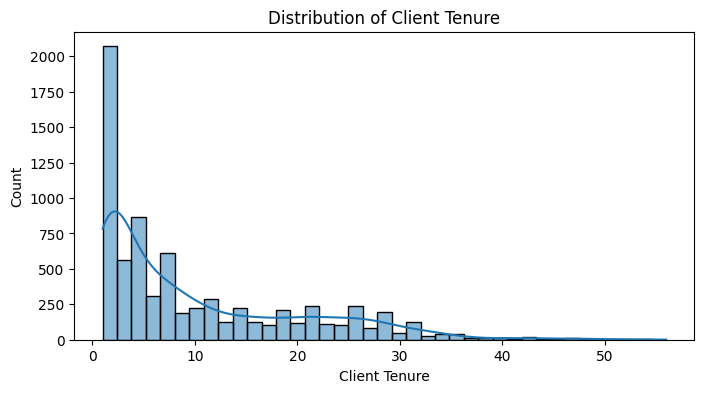

In [196]:
# Use eda_data dataframe to see if deleting the outlier row affects distribution
eda_data = ml_data.drop(high_tenure_rows.index)

# Graph distribution plot of employee column without the outlier
plt.figure(figsize=(8, 4))
sns.histplot(eda_data["clienttenure"], kde=True)
plt.title("Distribution of Client Tenure")
plt.xlabel("Client Tenure")
plt.ylabel("Count")
plt.show() #shows a much better distribution

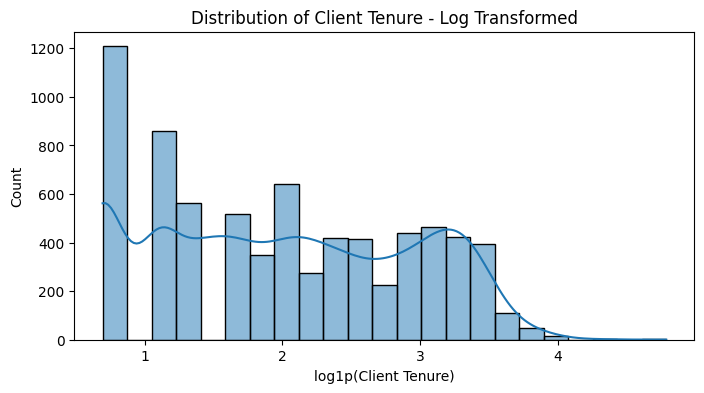

In [197]:
# Log transform clienttenure column to see if dropping or log is best
tenure_log = np.log1p(ml_data["clienttenure"])

plt.figure(figsize=(8, 4))
sns.histplot(tenure_log, kde=True)
plt.title("Distribution of Client Tenure - Log Transformed")
plt.xlabel("log1p(Client Tenure)")
plt.ylabel("Count")
plt.show()

In [199]:
# Investigate client tenure column for outliers
low_tenure_rows = ml_data[ml_data["clienttenure"] < 0]

low_tenure_rows

,employerid,offered,status,clienttenure,employees,industry,networkstrength,zipcode,city,latitude,longitude,fips,county,population,state,cbsa,cbsa_name


In [ ]:
# Investigate population column for outliers
high_population_rows = ml_data[ml_data["population"] > 9800500]

high_population_rows # this shows all outliers are from cali, with around the same number, very possible and plausible

,employerid,offered,status,clienttenure,employees,industry,networkstrength,zipcode,city,latitude,longitude,fips,county,population,state,cbsa,cbsa_name
10,589766893,ProductX,0,26,68,I20,0.5411,90016,los_angeles,34.029711,-118.35255,6037.0,los_angeles_county,9818605.0,CA,31080,los_angeles-long_beach-anaheim
15,695654073,ProductX,1,6,17,NaN,0.5411,90266,manhattan_beach,33.888980,-118.40535,6037.0,los_angeles_county,9818605.0,CA,31080,los_angeles-long_beach-anaheim
65,446319401,ProductX,1,4,41,I09,0.5411,90404,santa_monica,34.026959,-118.47432,6037.0,los_angeles_county,9818605.0,CA,31080,los_angeles-long_beach-anaheim
245,198953343,ProductX,0,5,4,I20,0.5411,90040,los_angeles,33.997492,-118.15284,6037.0,los_angeles_county,9818605.0,CA,31080,los_angeles-long_beach-anaheim
255,779909,ProductX,0,7,10,NaN,0.5411,90067,los_angeles,34.056709,-118.41183,6037.0,los_angeles_county,9818605.0,CA,31080,los_angeles-long_beach-anaheim
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7257,514447466,ProductX,0,2,15,I25,0.5411,91107,pasadena,34.151066,-118.08974,6037.0,los_angeles_county,9818605.0,CA,31080,los_angeles-long_beach-anaheim
7353,512326184,ProductX,0,2,9,NaN,0.5411,91364,woodland_hills,34.158214,-118.60061,6037.0,los_angeles_county,9818605.0,CA,31080,los_angeles-long_beach-anaheim
7374,476394,ProductX,0,32,149,I13,0.5411,90045,los_angeles,33.960041,-118.39490,6037.0,los_angeles_county,9818605.0,CA,31080,los_angeles-long_beach-anaheim
7390,675343175,ProductX,0,1,19,NaN,0.5411,91316,encino,34.168753,-118.51636,6037.0,los_angeles_county,9818605.0,CA,31080,los_angeles-long_beach-anaheim


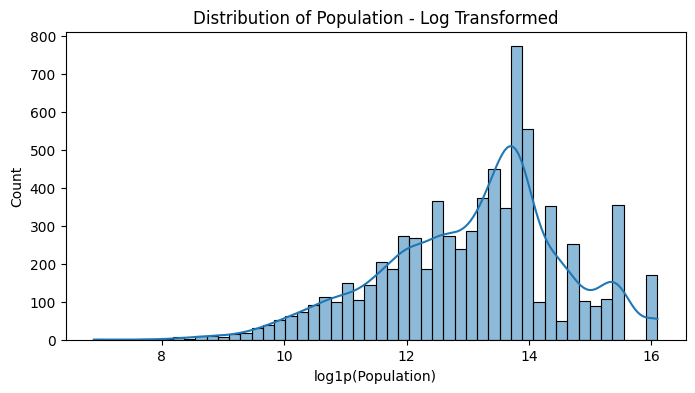

In [211]:
# Log transform population column to see if dropping or log is best
population_log = np.log1p(ml_data["population"])

plt.figure(figsize=(8, 4))
sns.histplot(population_log, kde=True)
plt.title("Distribution of Population - Log Transformed")
plt.xlabel("log1p(Population)")
plt.ylabel("Count")
plt.show()

In [ ]:
# Inspect lat and long ranges
invalid_geo = ml_data[
    (ml_data["latitude"] < -90) |
    (ml_data["latitude"] > 90) |
    (ml_data["longitude"] < -180) |
    (ml_data["longitude"] > 180)
]

invalid_geo[["latitude", "longitude", "city", "state", "zipcode"]]  # this shows that outlier ranges are valid, could just be where the locatio is

,latitude,longitude,city,state,zipcode


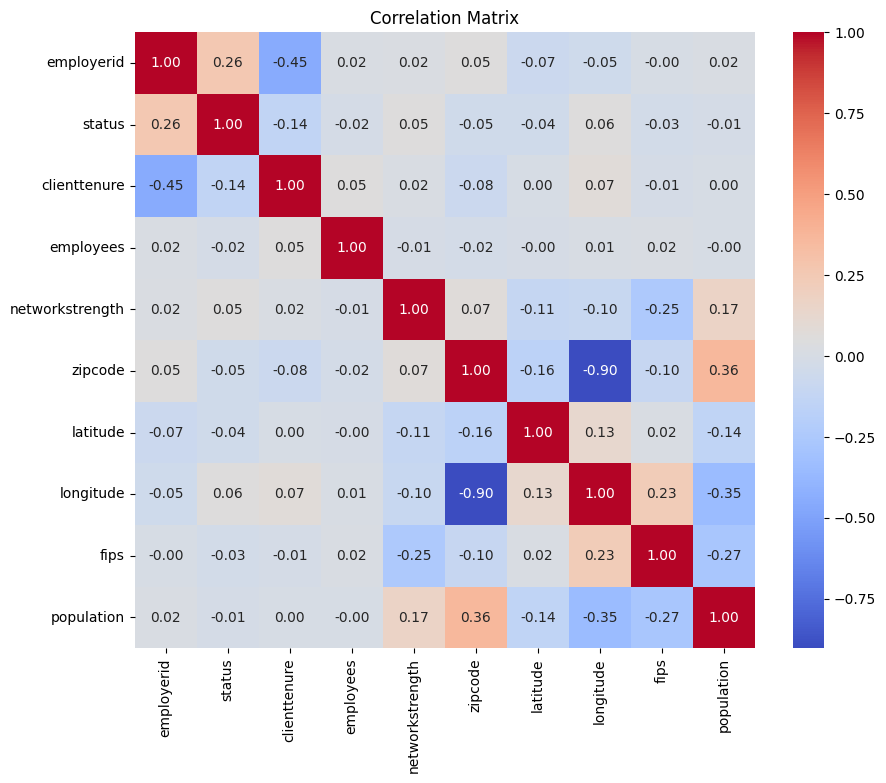

In [ ]:
# Correlation matrix
correlation_matrix = numeric_columns.corr()
correlation_matrix["status"].sort_values(ascending=False)

# Graph the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Split the data

In [ ]:
# Check the distribution of the target variable
print(ml_data["status"].value_counts()) # target is imbalanced with more results in the lost category than sold

# Remove obvious columns that won't be used in modeling
drop_cols = [
    "status",      # target
    "employerid",  # ID, not a real predictive feature
    "zipcode",     # location code, not usually meaningful as a number
    "fips"         # another geographic code
]

# Test train split
X = ml_data.drop(columns=drop_cols)
y = ml_data["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

status
0    4841
1    1143
Name: count, dtype: int64


### Preprocessing

In [266]:
# Import packages for modeling
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Install xgboost if it's not already installed
#!pip install xgboost
from xgboost import XGBClassifier


In [ ]:
# Define numeric and categorical features for preprocessing
numeric_features = ["clienttenure", "employees", "networkstrength", "latitude", "longitude", "population"]

categorical_features = ["industry", "state", "county", "cbsa", "cbsa_name"]

# Define preprocessing for numeric features
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("scaler", StandardScaler())
])

In [258]:
# Create separate preprocessors for one-hot encoding and ordinal encoding
onehot_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

ordinal_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ]
)

In [259]:
# Define models with different preprocessing techniques and their hyperparameters for tuning
experiment_models = {
    "logreg_onehot": {
        "pipeline": Pipeline([
            ("preprocessor", onehot_preprocessor),
            ("model", LogisticRegression(max_iter=1000))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["lbfgs"]
        }
    },

    "random_forest": {
        "pipeline": Pipeline([
            ("preprocessor", ordinal_preprocessor),
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [200, 500],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_leaf": [1, 2, 5]
        }
    },

    "xgboost": {
        "pipeline": Pipeline([
            ("preprocessor", ordinal_preprocessor),
            ("model", XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 500],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [3, 5],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    }
}

In [ ]:
# Loop through models and perform RandomizedSearchCV for hyperparameter tuning
results = {}

for name, config in experiment_models.items():
    print(f"Training {name}...")

    random_search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=25,
        cv=5,
        scoring="roc_auc",
        random_state=42,
        n_jobs=-1
    )
    
    # Fit the random search to the training data
    random_search.fit(X_train, y_train)

    # Store results
    results[name] = {
        "best_score": random_search.best_score_,
        "best_params": random_search.best_params_,
        "best_model": random_search.best_estimator_
    }

Training logreg_onehot...


c:\Users\exi0\.conda\envs\ml-zoomcamp\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=25. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Training random_forest...


c:\Users\exi0\.conda\envs\ml-zoomcamp\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 18 is smaller than n_iter=25. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Training xgboost...


In [261]:
# Print results
for name, result in results.items():
    print(f"{name}: Best AUC = {result['best_score']:.4f}, Best Params = {result['best_params']}")

logreg_onehot: Best AUC = 0.6563, Best Params = {'model__solver': 'lbfgs', 'model__C': 0.1}
random_forest: Best AUC = 0.6837, Best Params = {'model__n_estimators': 500, 'model__min_samples_leaf': 5, 'model__max_depth': 10}
xgboost: Best AUC = 0.6888, Best Params = {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}


In [267]:
# Evaluate best models with cross-validation predictions
for name, result in results.items():
    model = result["best_model"]

    y_pred = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=5
    )

    y_proba = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=5,
        method="predict_proba"
    )[:, 1]

    print(f"\n{name}")
    print("-" * 50)
    print("Best RandomizedSearchCV ROC-AUC:", result["best_score"])
    print("Cross-val ROC-AUC:", roc_auc_score(y_train, y_proba))
    print(classification_report(y_train, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_train, y_pred))


logreg_onehot
--------------------------------------------------
Best RandomizedSearchCV ROC-AUC: 0.6563265431170835
Cross-val ROC-AUC: 0.6559470926800473
              precision    recall  f1-score   support

           0       0.81      1.00      0.89      3388
           1       0.33      0.00      0.00       800

    accuracy                           0.81      4188
   macro avg       0.57      0.50      0.45      4188
weighted avg       0.72      0.81      0.72      4188

Confusion Matrix:
[[3384    4]
 [ 798    2]]

random_forest
--------------------------------------------------
Best RandomizedSearchCV ROC-AUC: 0.683655673890973
Cross-val ROC-AUC: 0.6833297668240851
              precision    recall  f1-score   support

           0       0.81      0.99      0.89      3388
           1       0.48      0.04      0.08       800

    accuracy                           0.81      4188
   macro avg       0.65      0.52      0.49      4188
weighted avg       0.75      0.81      0.74  